# **Data Preprocessing**

In [11]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split

Data Loading

In [12]:
df = pd.read_excel('premiums_young_with_gr.xlsx')

In [13]:
df.shape

(20096, 14)

In [14]:
df.head(5)

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount,Genetical_Risk
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,4
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050,3
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857,4
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,No Disease,Bronze,5684,2
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,No Disease,Bronze,5712,1


In [15]:
df.describe()

,Age,Number Of Dependants,Income_Lakhs,Annual_Premium_Amount,Genetical_Risk
count,20096.000000,20096.000000,20096.000000,20096.000000,20096.000000
mean,21.494029,0.718004,22.506519,8141.941033,2.503881
std,2.294050,0.940767,23.418644,2749.609551,1.710115
min,18.000000,-3.000000,1.000000,3501.000000,0.000000
25%,19.000000,0.000000,6.000000,6022.000000,1.000000
50%,21.500000,0.000000,16.000000,7939.000000,3.000000
75%,23.000000,1.000000,31.000000,9561.000000,4.000000
max,25.000000,3.000000,790.000000,18186.000000,5.000000


In [16]:
df.columns

Index(['Age', 'Gender', 'Region', 'Marital_status', 'Number Of Dependants',
       'BMI_Category', 'Smoking_Status', 'Employment_Status', 'Income_Level',
       'Income_Lakhs', 'Medical History', 'Insurance_Plan',
       'Annual_Premium_Amount', 'Genetical_Risk'],
      dtype='object')

In [17]:
df.columns = df.columns.str.replace(" ","_").str.lower()

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20096 entries, 0 to 20095
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   age                    20096 non-null  int64 
 1   gender                 20096 non-null  object
 2   region                 20096 non-null  object
 3   marital_status         20096 non-null  object
 4   number_of_dependants   20096 non-null  int64 
 5   bmi_category           20096 non-null  object
 6   smoking_status         20094 non-null  object
 7   employment_status      20095 non-null  object
 8   income_level           20092 non-null  object
 9   income_lakhs           20096 non-null  int64 
 10  medical_history        20096 non-null  object
 11  insurance_plan         20096 non-null  object
 12  annual_premium_amount  20096 non-null  int64 
 13  genetical_risk         20096 non-null  int64 
dtypes: int64(5), object(9)
memory usage: 2.1+ MB


In [19]:
df.isna().mean()*100

age                      0.000000
gender                   0.000000
region                   0.000000
marital_status           0.000000
number_of_dependants     0.000000
bmi_category             0.000000
smoking_status           0.009952
employment_status        0.004976
income_level             0.019904
income_lakhs             0.000000
medical_history          0.000000
insurance_plan           0.000000
annual_premium_amount    0.000000
genetical_risk           0.000000
dtype: float64

In [20]:
df['income_level'].unique()

array(['> 40L', '<10L', '10L - 25L', '25L - 40L', nan], dtype=object)

In [21]:
df[df['income_level'].isna()]

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk
379,20,Female,Southeast,Unmarried,0,Normal,No Smoking,Self-Employed,NaN,5,No Disease,Bronze,7191,3
7634,23,Female,Southwest,Unmarried,1,Underweight,No Smoking,NaN,NaN,8,No Disease,Bronze,5873,2
9813,18,Male,Southwest,Married,3,Normal,Occasional,Freelancer,NaN,6,No Disease,Silver,8484,1
15037,19,Male,Southeast,Unmarried,0,Overweight,Occasional,Salaried,NaN,3,No Disease,Silver,9174,1


In [22]:
df['employment_status'].unique()

array(['Self-Employed', 'Freelancer', 'Salaried', nan], dtype=object)

In [23]:
df['medical_history'].unique()

array(['High blood pressure', 'No Disease',
       'Diabetes & High blood pressure', 'Diabetes & Heart disease',
       'Diabetes', 'Diabetes & Thyroid', 'Heart disease', 'Thyroid',
       'High blood pressure & Heart disease'], dtype=object)

In [24]:
df[df['smoking_status'].isna()]

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk
6853,23,Male,Southwest,Unmarried,0,Normal,NaN,Freelancer,<10L,3,No Disease,Bronze,6001,2
7757,19,Female,Northeast,Unmarried,0,Normal,NaN,Salaried,10L - 25L,23,No Disease,Bronze,9010,5


In [25]:
df[(df['medical_history'] == 'High blood pressure & Heart disease') & (df['bmi_category'] == 'Overweight')]['smoking_status'].mode()

0    No Smoking
Name: smoking_status, dtype: object

In [26]:
smoking_mode = (
    df.groupby(['medical_history', 'bmi_category'])['smoking_status']
    .agg(lambda x: pd.Series.mode(x)[0] if not pd.Series.mode(x).empty else None)
    .reset_index()
)

print(smoking_mode)

                        medical_history bmi_category smoking_status
0                              Diabetes       Normal     No Smoking
1                              Diabetes      Obesity     No Smoking
2                              Diabetes   Overweight     No Smoking
3                              Diabetes  Underweight     No Smoking
4              Diabetes & Heart disease       Normal     No Smoking
5              Diabetes & Heart disease      Obesity     No Smoking
6              Diabetes & Heart disease   Overweight     No Smoking
7              Diabetes & Heart disease  Underweight     No Smoking
8        Diabetes & High blood pressure       Normal     No Smoking
9        Diabetes & High blood pressure      Obesity     No Smoking
10       Diabetes & High blood pressure   Overweight     No Smoking
11       Diabetes & High blood pressure  Underweight     No Smoking
12                   Diabetes & Thyroid       Normal     No Smoking
13                   Diabetes & Thyroid      Obe

In [27]:
"""
Handling Missing Values:

- income_level:
  Missingness is likely dependent on the observed feature income_lakhs,
  as both represent income information. Hence, this is classified as MAR
  (Missing At Random). I impute income_level using income_lakhs.

- smoking_status:
  Missingness is likely related to the unobserved value itself, as individuals
  may choose not to disclose their smoking habits. Therefore, it is classified
  as MNAR (Missing Not At Random). Instead of naive imputation, I treat missing
  values as a separate category ('Unknown') and optionally create a missing indicator.

- employment_status:
  Missingness does not appear to depend on the value itself but may depend on
  other observed features such as income_level. Hence, it is treated as MAR.
  I impute missing values using conditional mode imputation based on income_level.
"""


"\nHandling Missing Values:\n\n- income_level:\n  Missingness is likely dependent on the observed feature income_lakhs,\n  as both represent income information. Hence, this is classified as MAR\n  (Missing At Random). I impute income_level using income_lakhs.\n\n- smoking_status:\n  Missingness is likely related to the unobserved value itself, as individuals\n  may choose not to disclose their smoking habits. Therefore, it is classified\n  as MNAR (Missing Not At Random). Instead of naive imputation, I treat missing\n  values as a separate category ('Unknown') and optionally create a missing indicator.\n\n- employment_status:\n  Missingness does not appear to depend on the value itself but may depend on\n  other observed features such as income_level. Hence, it is treated as MAR.\n  I impute missing values using conditional mode imputation based on income_level.\n"

In [28]:
def map_income_level(x):
    if pd.isna(x):
        return None
    elif x < 10:
        return '<10L'
    elif 10 <= x < 25:
        return '10L - 25L'
    elif 25 <= x < 40:
        return '25L - 40L'
    else:
        return '> 40L'

In [29]:
mask = df['income_level'].isna()
df.loc[mask, 'income_level'] = df.loc[mask, 'income_lakhs'].apply(map_income_level)

In [30]:
df['smoking_status'] = df['smoking_status'].fillna('Unknown')

In [31]:
global_mode = df['employment_status'].mode()[0]

def fill_mode_safe(series):
    mode = series.mode()
    return series.fillna(mode[0] if not mode.empty else global_mode)

df['employment_status'] = (
    df.groupby('income_level')['employment_status']
      .transform(fill_mode_safe)
)

In [32]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount,genetical_risk
count,20096.000000,20096.000000,20096.000000,20096.000000,20096.000000
mean,21.494029,0.718004,22.506519,8141.941033,2.503881
std,2.294050,0.940767,23.418644,2749.609551,1.710115
min,18.000000,-3.000000,1.000000,3501.000000,0.000000
25%,19.000000,0.000000,6.000000,6022.000000,1.000000
50%,21.500000,0.000000,16.000000,7939.000000,3.000000
75%,23.000000,1.000000,31.000000,9561.000000,4.000000
max,25.000000,3.000000,790.000000,18186.000000,5.000000


In [33]:
df['number_of_dependants'].value_counts()/len(df)*100

number_of_dependants
 0    54.040605
 1    27.209395
 2    11.101712
 3     7.538814
-3     0.059713
-1     0.049761
Name: count, dtype: float64

In [34]:
df['number_of_dependants'] = df['number_of_dependants'].abs()

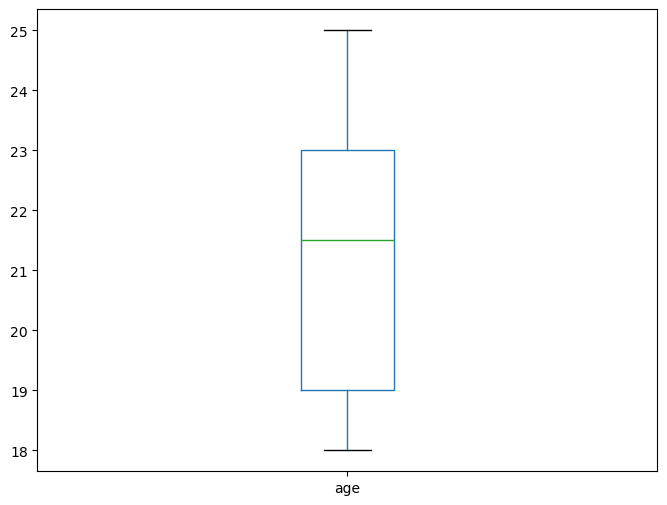

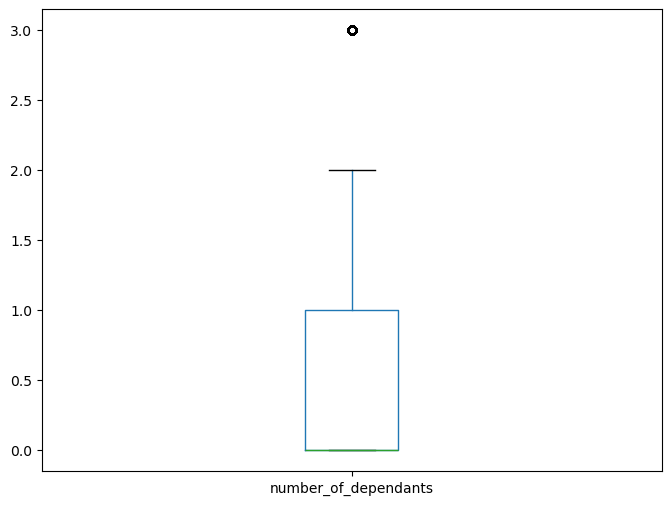

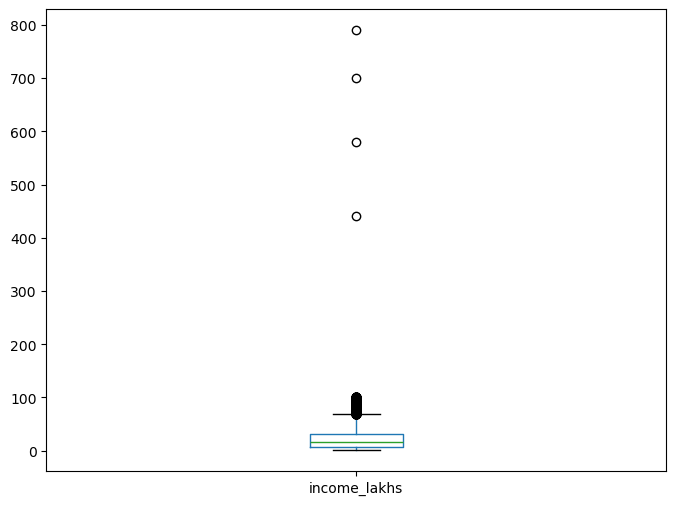

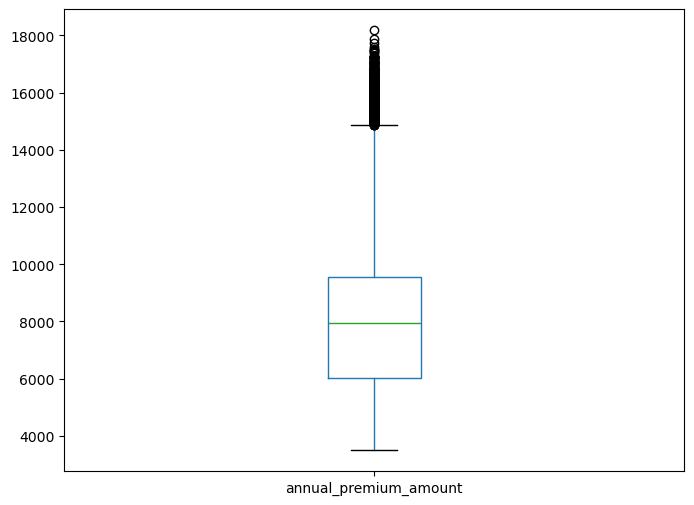

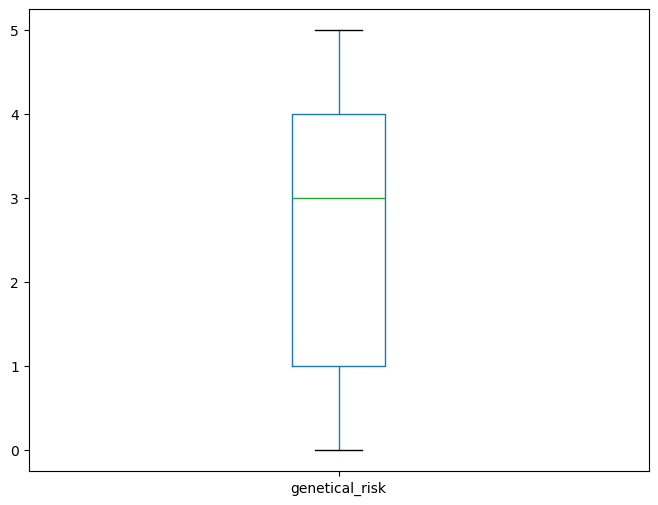

In [35]:
import matplotlib.pyplot as plt

numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns

for col in numeric_columns:
  df.boxplot(column=col, grid=False, figsize=(8, 6))
  plt.show()

In [36]:
def remove_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return df[(df[col] >= lower) & (df[col] <= upper)]

df = remove_outliers_iqr(df, 'age')

In [37]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount,genetical_risk
count,20096.000000,20096.000000,20096.000000,20096.000000,20096.000000
mean,21.494029,0.722582,22.506519,8141.941033,2.503881
std,2.294050,0.937255,23.418644,2749.609551,1.710115
min,18.000000,0.000000,1.000000,3501.000000,0.000000
25%,19.000000,0.000000,6.000000,6022.000000,1.000000
50%,21.500000,0.000000,16.000000,7939.000000,3.000000
75%,23.000000,1.000000,31.000000,9561.000000,4.000000
max,25.000000,3.000000,790.000000,18186.000000,5.000000


In [38]:
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
  print(f"{col}:{df[col].unique()}")

gender:['Male' 'Female']
region:['Northeast' 'Northwest' 'Southeast' 'Southwest']
marital_status:['Unmarried' 'Married']
bmi_category:['Overweight' 'Underweight' 'Normal' 'Obesity']
smoking_status:['Regular' 'No Smoking' 'Occasional' 'Smoking=0' 'Does Not Smoke'
 'Not Smoking' 'Unknown']
employment_status:['Self-Employed' 'Freelancer' 'Salaried']
income_level:['> 40L' '<10L' '10L - 25L' '25L - 40L']
medical_history:['High blood pressure' 'No Disease' 'Diabetes & High blood pressure'
 'Diabetes & Heart disease' 'Diabetes' 'Diabetes & Thyroid'
 'Heart disease' 'Thyroid' 'High blood pressure & Heart disease']
insurance_plan:['Silver' 'Bronze' 'Gold']


In [39]:
df.duplicated().sum()

0

In [40]:
df['smoking_status'] = df['smoking_status'].replace({
    'Not Smoking': 'No Smoking',
    'Does Not Smoke': 'No Smoking',
    'Smoking=0': 'No Smoking'
})

df['smoking_status'].unique()

array(['Regular', 'No Smoking', 'Occasional', 'Unknown'], dtype=object)

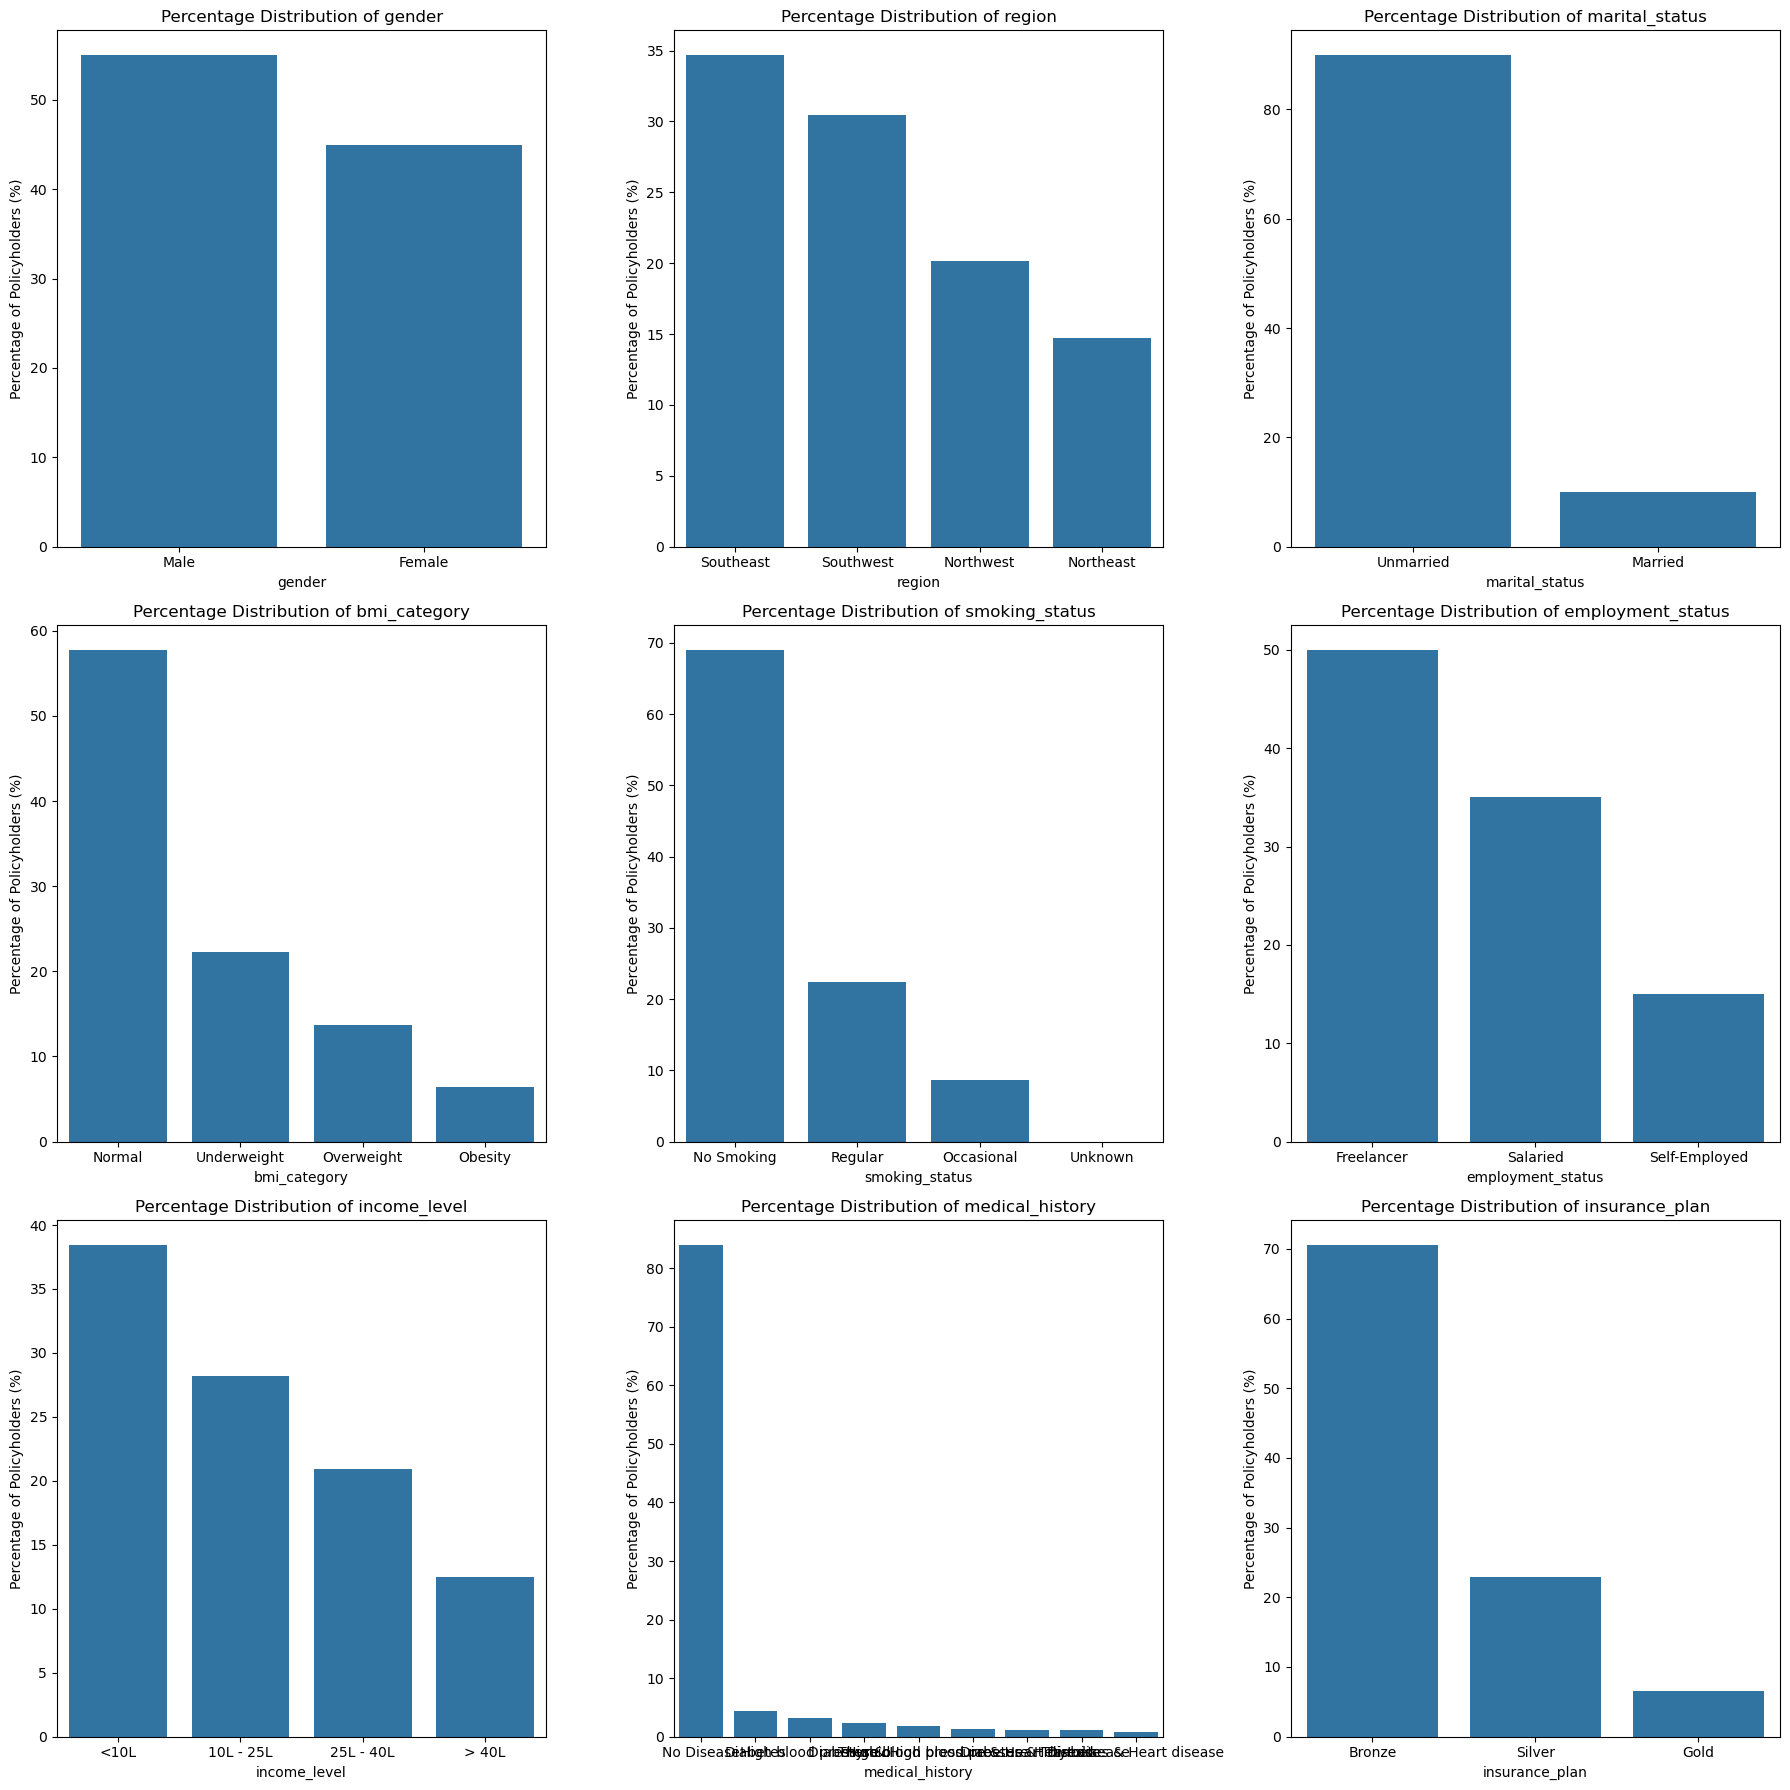

In [41]:
import seaborn as sns

fig, axes = plt.subplots(3, 3, figsize=(18, 18))  # Adjust figure size as necessary
axes = axes.flatten()  # Flatten the 2D array of axes into 1D for easier iteration

for ax, column in zip(axes, categorical_cols):
    # Calculate the percentage distribution of each category
    category_counts = df[column].value_counts(normalize=True) * 100  # normalize=True gives the relative frequencies

    # Plotting the distribution using barplot
    sns.barplot(x=category_counts.index, y=category_counts.values, ax=ax)
    ax.set_title(f'Percentage Distribution of {column}')
    ax.set_ylabel('Percentage of Policyholders (%)')
    ax.set_xlabel(column)  # Set xlabel to the column name for clarity

plt.tight_layout()  # Adjusts plot parameters for better fit in the figure window
plt.show()

In [42]:
crosstab = pd.crosstab(df['income_level'], df['insurance_plan'])
print(crosstab)

insurance_plan  Bronze  Gold  Silver
income_level                        
10L - 25L         4509   326     828
25L - 40L         3382   209     608
<10L              6175   404    1147
> 40L              116   366    2026


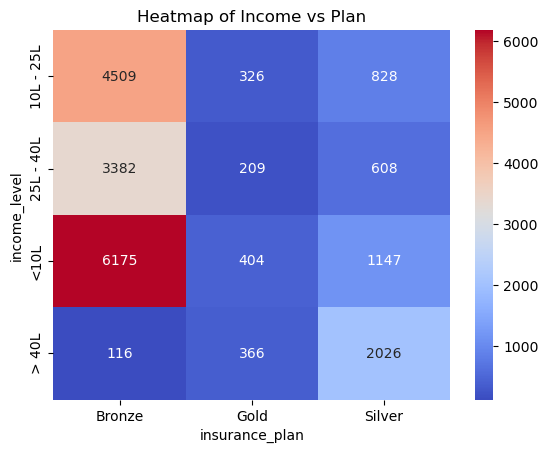

In [43]:
sns.heatmap(crosstab, annot=True, cmap='coolwarm',fmt="d")
plt.title('Heatmap of Income vs Plan')
plt.show()

In [44]:
risk_scores = {
    "diabetes": 6,
    "heart disease": 8,
    "high blood pressure":6,
    "thyroid": 5,
    "no disease": 0,
    "none":0
}

df[['disease1', 'disease2']] = df['medical_history'].str.split(" & ", expand=True).apply(lambda x: x.str.lower())
df['disease1'] = df['disease1'].fillna('none')
df['disease2'] = df['disease2'].fillna('none')
df['total_risk_score'] = 0

for disease in ['disease1', 'disease2']:
    df['total_risk_score'] += df[disease].map(risk_scores)

# Normalize the risk score to a range of 0 to 1
max_score = df['total_risk_score'].max()
min_score = df['total_risk_score'].min()
df['normalized_risk_score'] = (df['total_risk_score'] - min_score) / (max_score - min_score)
df.head(2)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,disease1,disease2,total_risk_score,normalized_risk_score
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,4,high blood pressure,none,6,0.428571
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050,3,no disease,none,0,0.000000


In [45]:
df['insurance_plan'] = df['insurance_plan'].map({'Bronze': 1, 'Silver': 2, 'Gold': 3})

In [46]:
df['income_level'] = df['income_level'].map({'<10L':1, '10L - 25L': 2, '25L - 40L':3, '> 40L':4})

In [47]:
nominal_cols = ['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status', 'employment_status']
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True, dtype=int)
df.head(3)

,age,number_of_dependants,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,disease1,disease2,...,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,smoking_status_Unknown,employment_status_Salaried,employment_status_Self-Employed
0,18,0,4,99,High blood pressure,2,13365,4,high blood pressure,none,...,0,1,0,1,0,0,1,0,0,1
1,22,0,1,3,No Disease,2,11050,3,no disease,none,...,0,1,0,0,1,0,0,0,0,0
2,21,0,4,97,No Disease,2,11857,4,no disease,none,...,0,1,0,0,0,0,1,0,1,0


In [48]:
df = df.drop(['medical_history','disease1', 'disease2', 'total_risk_score'], axis=1)
df.head(3)

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,genetical_risk,normalized_risk_score,gender_Male,region_Northwest,...,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,smoking_status_Unknown,employment_status_Salaried,employment_status_Self-Employed
0,18,0,4,99,2,13365,4,0.428571,1,0,...,0,1,0,1,0,0,1,0,0,1
1,22,0,1,3,2,11050,3,0.000000,0,1,...,0,1,0,0,1,0,0,0,0,0
2,21,0,4,97,2,11857,4,0.000000,0,0,...,0,1,0,0,0,0,1,0,1,0


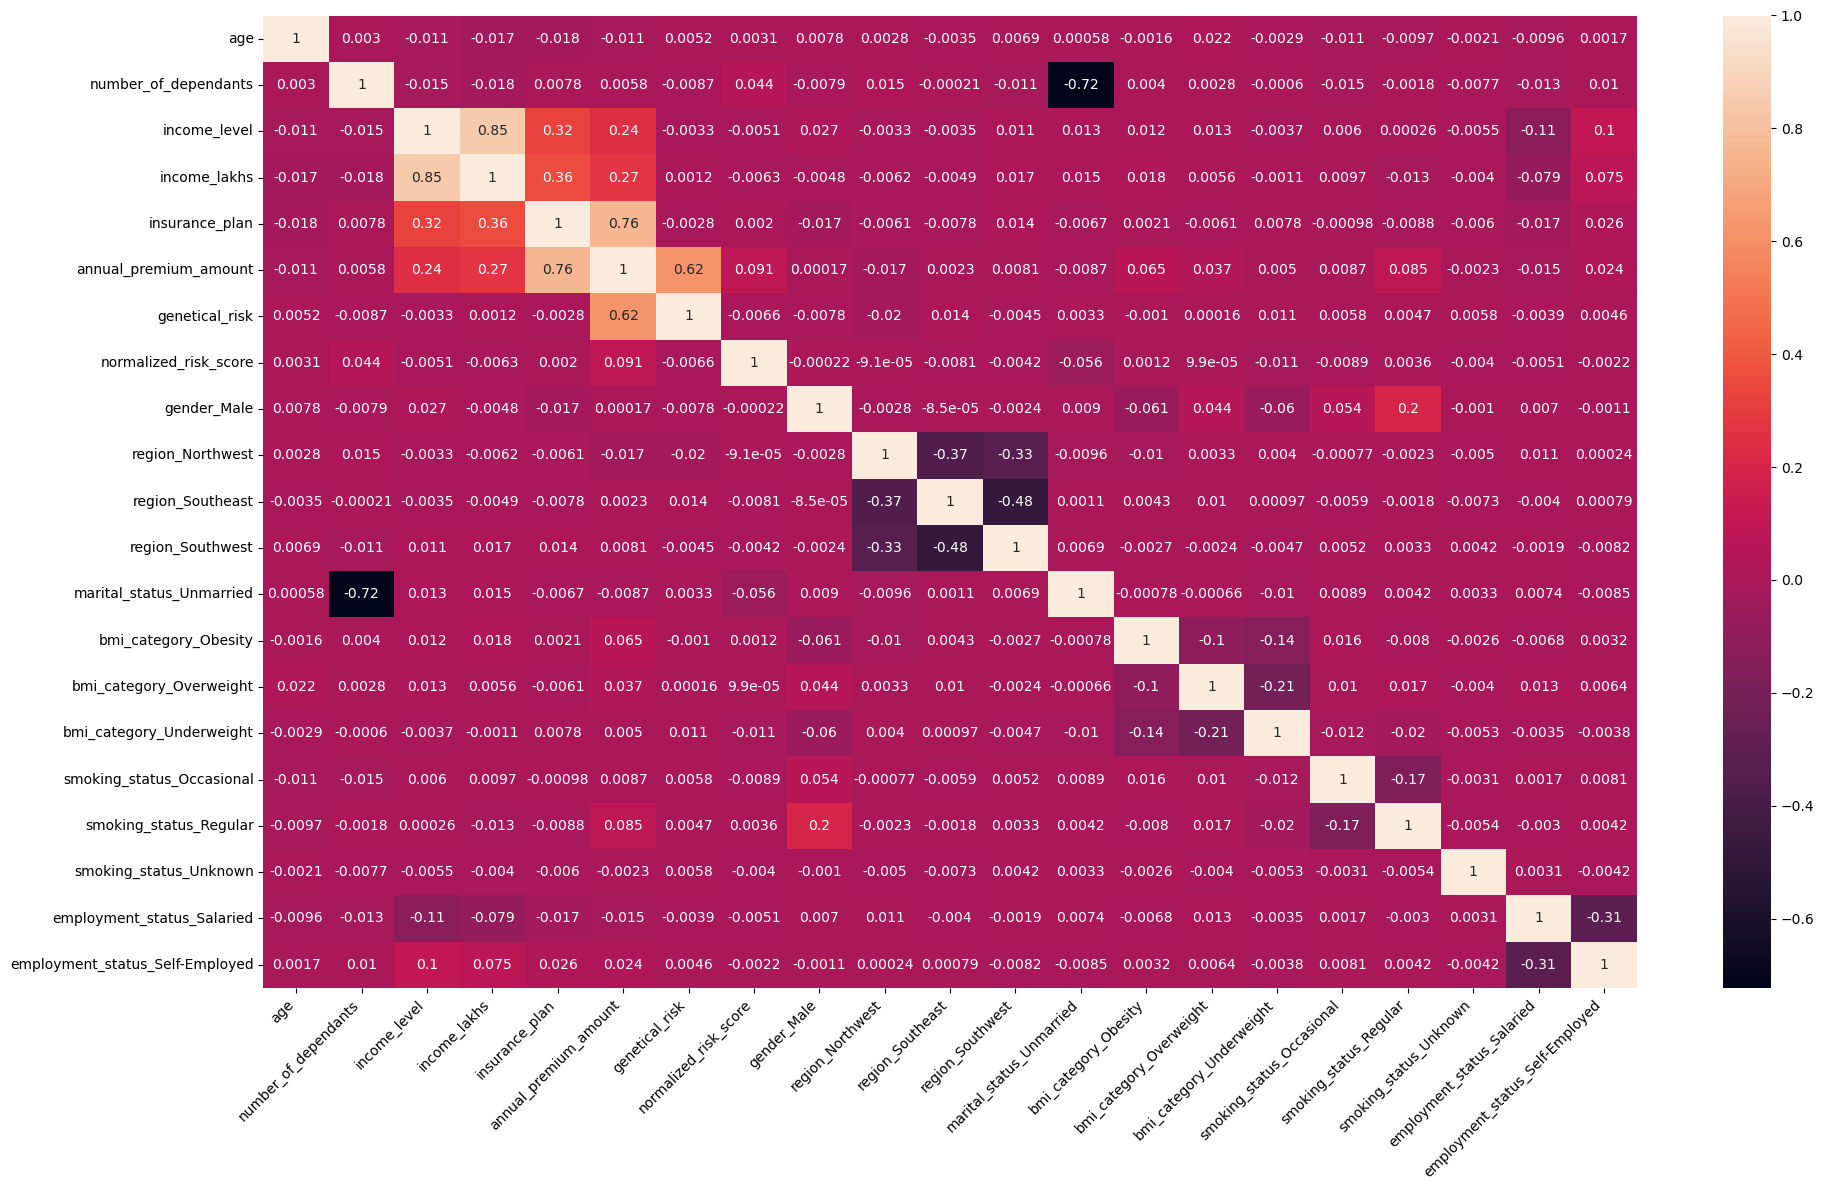

In [49]:
cm = df.corr()

plt.figure(figsize=(20,12))
sns.heatmap(cm, annot=True)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [50]:
X = df.drop('annual_premium_amount', axis='columns')
y = df['annual_premium_amount']

from sklearn.preprocessing import MinMaxScaler

cols_to_scale = ['age','number_of_dependants', 'income_level',  'income_lakhs', 'insurance_plan']
scaler = MinMaxScaler()

X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])
X.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,genetical_risk,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,smoking_status_Unknown,employment_status_Salaried,employment_status_Self-Employed
count,20096.000000,20096.000000,20096.000000,20096.000000,20096.000000,20096.000000,20096.000000,20096.000000,20096.000000,20096.000000,20096.000000,20096.000000,20096.000000,20096.000000,20096.000000,20096.000000,20096.000000,20096.000000,20096.000000,20096.000000
mean,0.499147,0.240861,0.358031,0.027258,0.179613,2.503881,0.092047,0.550259,0.201234,0.346935,0.304688,0.899881,0.063545,0.136495,0.222482,0.086485,0.223477,0.000100,0.350020,0.149930
std,0.327721,0.312418,0.347558,0.029681,0.300032,1.710115,0.229974,0.497480,0.400933,0.476007,0.460286,0.300167,0.243947,0.343322,0.415924,0.281086,0.416586,0.009976,0.476988,0.357012
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.142857,0.000000,0.000000,0.006337,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.500000,0.000000,0.333333,0.019011,0.000000,3.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.714286,0.333333,0.666667,0.038023,0.500000,4.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [51]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df['Column'] = data.columns
    vif_df['VIF'] = [variance_inflation_factor(data.values,i) for i in range(data.shape[1])]
    return vif_df

In [52]:
calculate_vif(X)

,Column,VIF
0,age,3.154639
1,number_of_dependants,1.930227
2,income_level,7.595530
3,income_lakhs,6.935810
4,insurance_plan,1.556910
5,genetical_risk,2.981141
6,normalized_risk_score,1.154480
7,gender_Male,2.310814
8,region_Northwest,2.154432
9,region_Southeast,2.990873


In [53]:
calculate_vif(X.drop('income_level', axis="columns"))

,Column,VIF
0,age,3.153216
1,number_of_dependants,1.924203
2,income_lakhs,2.103758
3,insurance_plan,1.553949
4,genetical_risk,2.980992
5,normalized_risk_score,1.154437
6,gender_Male,2.300312
7,region_Northwest,2.153233
8,region_Southeast,2.989200
9,region_Southwest,2.744384


In [54]:
# # we will drop income_lakhs due to high VIF value
# X_reduced = X.drop('income_level', axis="columns")

<h2 align="center" style="color:blue">Model Training</h2>

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=10)

# shape of the X_train, X_test, y_train, y_test features
print("x train: ",X_train.shape)
print("x test: ",X_test.shape)
print("y train: ",y_train.shape)
print("y test: ",y_test.shape)

x train:  (14067, 20)
x test:  (6029, 20)
y train:  (14067,)
y test:  (6029,)


In [56]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
test_score = model_lr.score(X_test, y_test)
train_score = model_lr.score(X_train, y_train)
train_score, test_score

(0.9884313467093264, 0.9884286665613233)

In [57]:
y_pred = model_lr.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred)
rmse_lr = np.sqrt(mse_lr)
print("Linear Regression ==> MSE: ", mse_lr, "RMSE: ", rmse_lr)

Linear Regression ==> MSE:  88358.70608709363 RMSE:  297.25192360537153


In [58]:
X_test.shape

(6029, 20)

In [59]:
np.set_printoptions(suppress=True, precision=6)
model_lr.coef_

array([   1.35013 ,    8.275612,    6.970496, -137.291051, 6994.219394,
        998.847754, 1116.893511,    8.233183,    0.226109,    5.740013,
          1.307661,   -6.355144,  808.854234,  396.563436,  108.162282,
        190.195266,  608.774878,   12.92197 ,    2.653134,    2.016075])

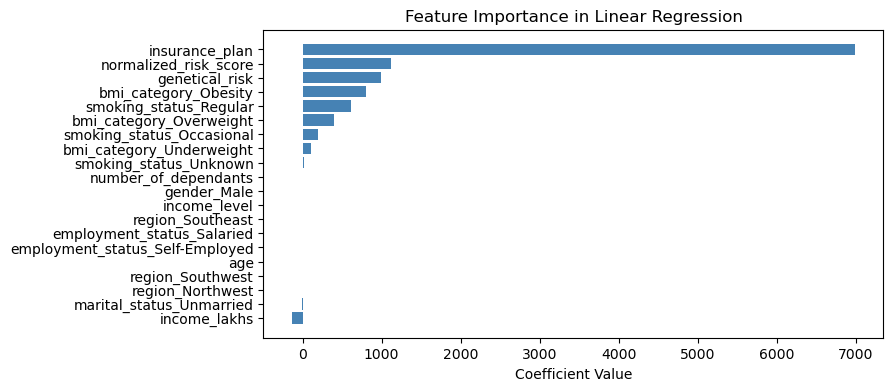

In [60]:
feature_importance = model_lr.coef_

# Create a DataFrame for easier handling
coef_df = pd.DataFrame(feature_importance, index=X_train.columns, columns=['Coefficients'])

# Sort the coefficients for better visualization
coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

# Plotting
plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in Linear Regression')
plt.show()

In [61]:
# Ridge Regression Model
model_rg = Ridge(alpha=1)
model_rg.fit(X_train, y_train)
test_score = model_rg.score(X_test, y_test)
train_score = model_rg.score(X_train, y_train)
train_score, test_score

(0.9884308490609366, 0.9884255806965514)

In [62]:
y_pred = model_rg.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred)
rmse_lr = np.sqrt(mse_lr)
print("Ridge Regression ==> MSE: ", mse_lr, "RMSE: ", rmse_lr)

Ridge Regression ==> MSE:  88382.2697515452 RMSE:  297.29155681173523


In [63]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor(n_estimators=20, max_depth=3)
model_xgb.fit(X_train, y_train)
model_xgb.score(X_test, y_test)

0.9872895612723853

In [64]:
y_pred = model_xgb.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred)
rmse_lr = np.sqrt(mse_lr)
print("XGBoost Regression ==> MSE: ", mse_lr, "RMSE: ", rmse_lr)

XGBoost Regression ==> MSE:  97056.91446220738 RMSE:  311.5395873114802


In [65]:
model_xgb = XGBRegressor()
param_grid = {
    'n_estimators': [20, 40, 50],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
}
random_search = RandomizedSearchCV(model_xgb, param_grid, n_iter=10, cv=3, scoring='r2', random_state=42, n_jobs=None)
random_search.fit(X_train, y_train)
random_search.best_score_

0.9880701758889124

In [66]:
random_search.best_params_

{'n_estimators': 50, 'max_depth': 5, 'learning_rate': 0.1}

In [67]:
best_model = model_lr

In [68]:
y_pred = best_model.predict(X_test)

residuals = y_pred - y_test
residuals_pct = (residuals / y_test) * 100

results_df = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred,
    'diff': residuals,
    'diff_pct': residuals_pct
})
results_df.head()

,actual,predicted,diff,diff_pct
4797,6696,7004.404950,308.404950,4.605809
14476,10073,10125.437375,52.437375,0.520574
11142,9524,9919.949984,395.949984,4.157392
15008,4553,4610.527453,57.527453,1.263507
18245,8814,8383.724752,-430.275248,-4.881725


In [69]:
X_test.columns

Index(['age', 'number_of_dependants', 'income_level', 'income_lakhs',
       'insurance_plan', 'genetical_risk', 'normalized_risk_score',
       'gender_Male', 'region_Northwest', 'region_Southeast',
       'region_Southwest', 'marital_status_Unmarried', 'bmi_category_Obesity',
       'bmi_category_Overweight', 'bmi_category_Underweight',
       'smoking_status_Occasional', 'smoking_status_Regular',
       'smoking_status_Unknown', 'employment_status_Salaried',
       'employment_status_Self-Employed'],
      dtype='object')

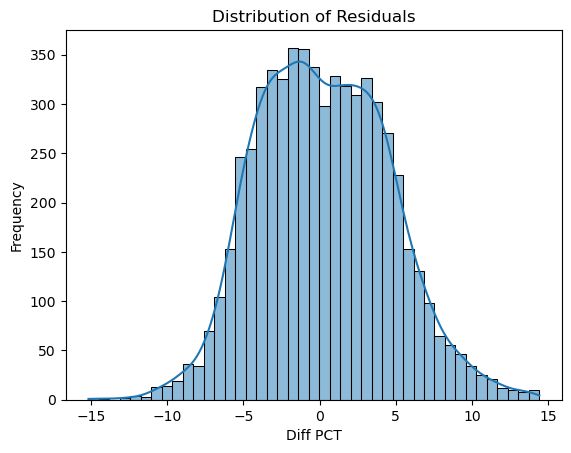

In [ ]:
sns.histplot(results_df['diff_pct'], kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Diff PCT')
plt.ylabel('Frequency')
plt.show()

In [ ]:
extreme_error_threshold = 10  # You can adjust this threshold based on your domain knowledge or requirements
extreme_results_df = results_df[np.abs(results_df['diff_pct']) > extreme_error_threshold]
extreme_results_df.head()

,actual,predicted,diff,diff_pct
6506,3539,3999.105044,460.105044,13.000990
18987,5861,5038.541944,-822.458056,-14.032726
19580,5376,5954.917779,578.917779,10.768560
5604,4260,4720.844752,460.844752,10.817952
7423,3537,4013.441321,476.441321,13.470210


In [ ]:
extreme_errors_pct = extreme_results_df.shape[0]*100/X_test.shape[0]
extreme_errors_pct

2.0898988223586

In [ ]:
from joblib import dump

dump(best_model, "model_young.joblib")
scaler_with_cols = {
    'scaler': scaler,
    'cols_to_scale': cols_to_scale
}
dump(scaler_with_cols, "scaler_young.joblib")

['scaler_young.joblib']

In [ ]:
scaler_with_cols

{'scaler': MinMaxScaler(),
 'cols_to_scale': ['age',
  'number_of_dependants',
  'income_level',
  'income_lakhs',
  'insurance_plan']}